# Compare GMM calibrations

## Purpose

This is an isolated notebook to compare the metrics datafiles produced as part of the Com galaxy/CSS colour pipeline.

The metrics csv files will be called `"../Coma_CSS_color/data/metrics_df_fiducial_orig.csv"` for the old cal data and `"../Coma_CSS_color/data/metrics_df_fiducial_orig_recal.csv"` for the new cal data.

Initially this will be diagnostic checking, to establish exactly what changed, how much, and whether galaxy rankings changed.


## Load the `csv` files

Load the two outputs and sanity-check them

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr


OLD_FILE = "../Coma_CSS_color/data/metrics_df_fiducial_orig.csv"
NEW_FILE = "../Coma_CSS_color/data/metrics_df_fiducial_orig_recal.csv"

old = pd.read_csv(OLD_FILE)
new = pd.read_csv(NEW_FILE)

print("Original calibration:", old.shape)
print("Recalibrated:        ", new.shape)


Original calibration: (174, 158)
Recalibrated:         (174, 158)


## Compare the schemas


In [18]:
old_only = sorted(set(old.columns) - set(new.columns))
new_only = sorted(set(new.columns) - set(old.columns))
common = sorted(set(old.columns) & set(new.columns))

print("Columns only in original:")
print(old_only)

print("\nColumns only in recalibrated:")
print(new_only)

print(f"\nCommon columns: {len(common)}")

Columns only in original:
[]

Columns only in recalibrated:
[]

Common columns: 158


In [19]:
display(pd.DataFrame({
    "column": common,
    "old_dtype": [old[c].dtype for c in common],
    "new_dtype": [new[c].dtype for c in common],
}))


,column,old_dtype,new_dtype
0,A_ap_eff,float64,float64
1,A_ap_eff_over_geom,float64,float64
2,A_ap_geom,float64,float64
3,A_bg_eff,float64,float64
4,A_bg_eff_over_geom,float64,float64
...,...,...,...
153,sum_Pblue_annulus,float64,float64
154,sum_Pblue_inner,float64,float64
155,tidal_proxy,float64,float64
156,z,float64,float64


## Merge the files on the galaxy `name` key

Ideally, both datasets should contain exactly the same galaxies


In [20]:
print(old.columns.tolist())

KEY = "name"


['name', 'N_inner', 'N_annulus', 'A_ap_geom', 'A_bg_geom', 'A_ap_eff', 'A_bg_eff', 'A_ap_eff_over_geom', 'A_bg_eff_over_geom', 'f_cov_ap_geom', 'f_cov_bg_geom', 'cov_ap_depthw', 'cov_bg_depthw', 'coverage_ok_ap', 'coverage_ok_bg', 'coverage_ok_both', 'good_ap_area', 'good_bg_area', 'N_inner_color', 'N_annulus_color', 'median_color', 'median_color_bgsub', 'median_color_bgsub_geom', 'N_inner_Pblue', 'N_annulus_Pblue', 'Pblue_mean_inner_raw', 'Pblue_mean_annulus', 'median_color_inner_raw', 'median_color_annulus', 'mean_color_inner_raw', 'mean_color_annulus', 'alpha_eff', 'alpha_geom', 'N_eff_bgsub_color', 'N_eff_bgsub_Pblue', 'N_geom_bgsub_color', 'N_geom_bgsub_Pblue', 'sum_Pblue_inner', 'sum_Pblue_annulus', 'Pblue_std_inner', 'Pblue_std_annulus', 'color_std_inner', 'color_std_annulus', 'Pblue_inner_meets_min', 'Pblue_annulus_nonzero', 'min_gc_for_Pblue', 'Pblue_mean', 'Pblue_mean_err', 'Pblue_mean_bgsub', 'Pblue_mean_bgsub_geom', 'fb', 'fb_err', 'fb_bgsub', 'mu_blue', 'mu_blue_err', 'mu_

Merge...

In [21]:
cmp = old.merge(
    new,
    on=KEY,
    suffixes=("_old", "_new"),
    how="outer",
    validate="one_to_one",
    indicator=True
)

print(cmp["_merge"].value_counts())


_merge
both          174
left_only       0
right_only      0
Name: count, dtype: int64


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_3803/2514182660.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cmp = old.merge(
/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_3803/2514182660.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cmp = old.merge(
/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_3803/2514182660.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining a

# Analysis

## Indentify changed numerical quantities


In [22]:
from pandas.api.types import is_numeric_dtype, is_bool_dtype

numeric_common = [
    c for c in common
    if c != KEY
    and is_numeric_dtype(old[c])
    and is_numeric_dtype(new[c])
    and not is_bool_dtype(old[c])
    and not is_bool_dtype(new[c])
]

change_rows = []

for c in numeric_common:
    a = cmp[f"{c}_old"]
    b = cmp[f"{c}_new"]

    valid = a.notna() & b.notna()

    if valid.sum() == 0:
        continue

    delta = b[valid] - a[valid]

    change_rows.append({
        "column": c,
        "N": valid.sum(),
        "mean_old": a[valid].mean(),
        "mean_new": b[valid].mean(),
        "mean_delta": delta.mean(),
        "median_abs_delta": np.median(np.abs(delta)),
        "max_abs_delta": np.max(np.abs(delta)),
        "changed_N": np.sum(~np.isclose(a[valid], b[valid],
                                        equal_nan=True)),
    })

change_summary = (
    pd.DataFrame(change_rows)
    .sort_values("max_abs_delta", ascending=False)
)

display(change_summary)


,column,N,mean_old,mean_new,mean_delta,median_abs_delta,max_abs_delta,changed_N
119,sum_Pblue_inner,130,1.249518e+02,1.174692e+02,-7.482642,0.330150,297.882789,130
118,sum_Pblue_annulus,139,1.585949e+02,1.507343e+02,-7.860584,0.732322,281.334301,139
38,Pblue_std_inner,123,2.215692e-01,2.327180e-01,0.011149,0.012518,0.220638,123
37,Pblue_std_annulus,137,2.248923e-01,2.359857e-01,0.011093,0.013859,0.185314,137
29,Pblue_mean_annulus,139,6.029235e-01,5.878868e-01,-0.015037,0.016207,0.183378,139
...,...,...,...,...,...,...,...,...
115,rerr_model_sdss,162,5.068832e-02,5.068832e-02,0.000000,0.000000,0.000000,0
117,sdss_objid,162,1.237667e+18,1.237667e+18,0.000000,0.000000,0.000000,0
120,tidal_proxy,174,1.628717e+25,1.628717e+25,0.000000,0.000000,0.000000,0
121,z,174,2.313229e-02,2.313229e-02,0.000000,0.000000,0.000000,0


Most environmental/location quantities ought to be identical. Only quantities downstream of $P_\mathrm{blue}$ should move.

This will isolate the changed columns...


In [23]:
display(
    change_summary[
        change_summary["changed_N"] > 0
    ]
)


,column,N,mean_old,mean_new,mean_delta,median_abs_delta,max_abs_delta,changed_N
119,sum_Pblue_inner,130,124.951812,117.469170,-7.482642,0.330150,297.882789,130
118,sum_Pblue_annulus,139,158.594908,150.734324,-7.860584,0.732322,281.334301,139
38,Pblue_std_inner,123,0.221569,0.232718,0.011149,0.012518,0.220638,123
37,Pblue_std_annulus,137,0.224892,0.235986,0.011093,0.013859,0.185314,137
29,Pblue_mean_annulus,139,0.602924,0.587887,-0.015037,0.016207,0.183378,139
13,Delta_Pblue_mean_bgsub_geom,93,-0.089611,-0.085560,0.004051,0.016323,0.177364,93
32,Pblue_mean_bgsub_geom,93,0.099166,0.096489,-0.002677,0.014201,0.167370,93
28,Pblue_mean,93,0.568859,0.551270,-0.017589,0.018403,0.139967,93
66,fb,93,0.568859,0.551270,-0.017589,0.018403,0.139967,93
67,fb_bgsub,93,0.123881,0.120767,-0.003114,0.015225,0.138446,93


## Automatically isolate the important columns

... rather than hunting through 158 columns manually!

In [24]:
keywords = [
    "pblue",
    "blue",
    "fb",
    "delta",
    "density",
    "tidal",
    "bcg",
    "radius",
    "dist"
]

for keyword in keywords:
    matches = [
        c for c in common
        if keyword.lower() in c.lower()
    ]

    print(f"\n{keyword}:")
    print(matches)



pblue:
['Delta_Pblue_mean', 'Delta_Pblue_mean_bgsub', 'Delta_Pblue_mean_bgsub_geom', 'N_annulus_Pblue', 'N_eff_bgsub_Pblue', 'N_geom_bgsub_Pblue', 'N_inner_Pblue', 'Pblue_annulus_nonzero', 'Pblue_inner_meets_min', 'Pblue_mean', 'Pblue_mean_annulus', 'Pblue_mean_bgsub', 'Pblue_mean_bgsub_exp', 'Pblue_mean_bgsub_geom', 'Pblue_mean_bgsub_geom_exp', 'Pblue_mean_err', 'Pblue_mean_exp', 'Pblue_mean_inner_raw', 'Pblue_std_annulus', 'Pblue_std_inner', 'min_gc_for_Pblue', 'sum_Pblue_annulus', 'sum_Pblue_inner']

blue:
['Delta_Pblue_mean', 'Delta_Pblue_mean_bgsub', 'Delta_Pblue_mean_bgsub_geom', 'N_annulus_Pblue', 'N_eff_bgsub_Pblue', 'N_geom_bgsub_Pblue', 'N_inner_Pblue', 'Pblue_annulus_nonzero', 'Pblue_inner_meets_min', 'Pblue_mean', 'Pblue_mean_annulus', 'Pblue_mean_bgsub', 'Pblue_mean_bgsub_exp', 'Pblue_mean_bgsub_geom', 'Pblue_mean_bgsub_geom_exp', 'Pblue_mean_err', 'Pblue_mean_exp', 'Pblue_mean_inner_raw', 'Pblue_std_annulus', 'Pblue_std_inner', 'min_gc_for_Pblue', 'mu_blue', 'mu_blue_bgs

## Setup a comparison helper function

This will take the merged dataframe `cmp` and compare a named column

In [25]:
def compare_metric(cmp, column, key=KEY):
    
    old_col = f"{column}_old"
    new_col = f"{column}_new"

    sub = cmp[[key, old_col, new_col]].dropna().copy()

    sub["delta"] = sub[new_col] - sub[old_col]

    rho, p_rho = spearmanr(sub[old_col], sub[new_col])
    r, p_r = pearsonr(sub[old_col], sub[new_col])

    print(column)
    print("-" * len(column))
    print(f"N                   = {len(sub)}")
    print(f"Mean old            = {sub[old_col].mean():.5f}")
    print(f"Mean new            = {sub[new_col].mean():.5f}")
    print(f"Mean Δ(new-old)      = {sub['delta'].mean():+.5f}")
    print(f"Median |Δ|           = {sub['delta'].abs().median():.5f}")
    print(f"Maximum |Δ|          = {sub['delta'].abs().max():.5f}")
    print(f"Spearman old vs new  = {rho:.4f}  (p={p_rho:.3g})")
    print(f"Pearson old vs new   = {r:.4f}  (p={p_r:.3g})")

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        sub[old_col],
        sub[new_col],
        alpha=0.7
    )

    lim_min = min(sub[old_col].min(), sub[new_col].min())
    lim_max = max(sub[old_col].max(), sub[new_col].max())

    ax.plot(
        [lim_min, lim_max],
        [lim_min, lim_max],
        "--"
    )

    ax.set_xlabel(f"{column} — submitted calibration")
    ax.set_ylabel(f"{column} — recalibrated")
    ax.set_title(f"Old vs recalibrated: {column}")

    plt.show()

    return sub

and then to test this we use something like...

Delta_Pblue_mean_bgsub
----------------------
N                   = 93
Mean old            = -0.04558
Mean new            = -0.04081
Mean Δ(new-old)      = +0.00477
Median |Δ|           = 0.01649
Maximum |Δ|          = 0.13683
Spearman old vs new  = 0.9839  (p=7.19e-70)
Pearson old vs new   = 0.9917  (p=6.63e-83)


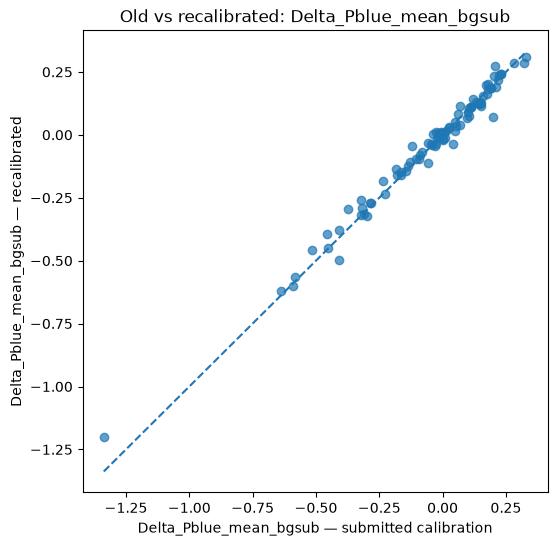

In [26]:
delta_fb_cmp = compare_metric(
    cmp,
    "Delta_Pblue_mean_bgsub"
)


## Explicitly examine changes in $\Delta f_\mathrm{b}$


In [27]:
METRIC = "Delta_Pblue_mean_bgsub"

cmp["delta_metric"] = (
    cmp[f"{METRIC}_new"] -
    cmp[f"{METRIC}_old"]
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_3803/515210373.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cmp["delta_metric"] = (


Then we can answer a different question from the old-vs-new plot, i.e., 

> Does the recalibration affect all galaxies similarly, or does the change depend systematically on their original $\Delta f_\mathrm{b}$?

using this plot...

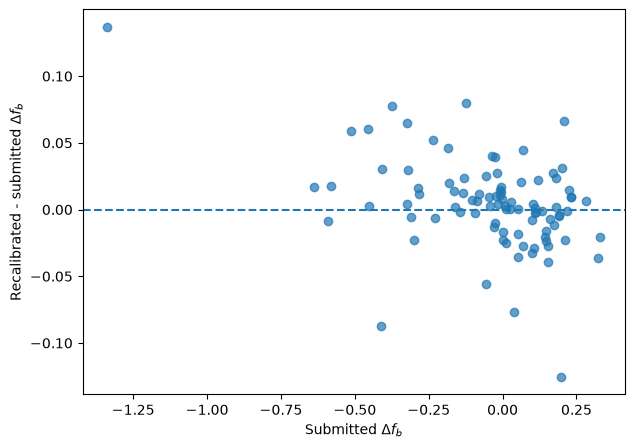

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    cmp[f"{METRIC}_old"],
    cmp["delta_metric"],
    alpha=0.7
)

ax.axhline(0, linestyle="--")

ax.set_xlabel(r"Submitted $\Delta f_b$")
ax.set_ylabel(r"Recalibrated - submitted $\Delta f_b$")

plt.show()

Add a sign-change check

Delta_Pblue_mean_bgsub
----------------------
N                   = 93
Mean old            = -0.04558
Mean new            = -0.04081
Mean Δ(new-old)      = +0.00477
Median |Δ|           = 0.01649
Maximum |Δ|          = 0.13683
Spearman old vs new  = 0.9839  (p=7.19e-70)
Pearson old vs new   = 0.9917  (p=6.63e-83)


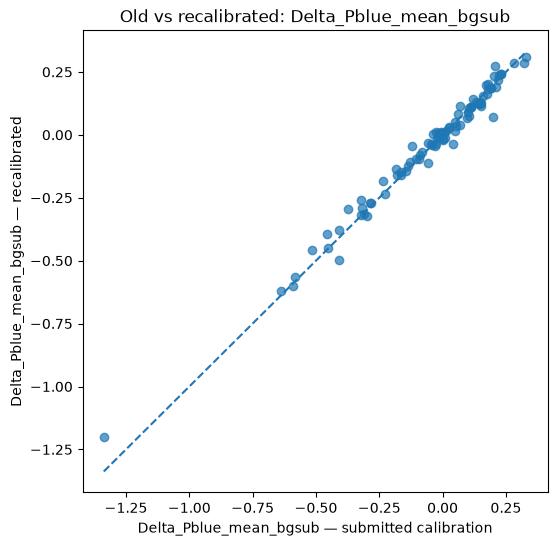

In [29]:
PRIMARY = "Delta_Pblue_mean_bgsub"

delta_fb_cmp = compare_metric(
    cmp,
    PRIMARY
)


This tells us how many galaxies actually move from blue-deficient to blue-enhanced or vice versa.

In [30]:
old_col = f"{PRIMARY}_old"
new_col = f"{PRIMARY}_new"

sub = cmp[[KEY, old_col, new_col]].dropna().copy()

sub["old_deficit"] = sub[old_col] < 0
sub["new_deficit"] = sub[new_col] < 0

print(pd.crosstab(
    sub["old_deficit"],
    sub["new_deficit"],
    rownames=["Original"],
    colnames=["Recalibrated"]
))


Recalibrated  False  True 
Original                  
False            42      4
True              8     39


and then we identify the galaxies most affected by the new GMM.

In [31]:
sub["delta_recal"] = sub[new_col] - sub[old_col]

display(
    sub.assign(abs_change=sub["delta_recal"].abs())
       .sort_values("abs_change", ascending=False)
       .head(20)
)


,name,Delta_Pblue_mean_bgsub_old,Delta_Pblue_mean_bgsub_new,old_deficit,new_deficit,delta_recal,abs_change
15,2MASX J12595670+2755483,-1.337645,-1.200813,True,True,0.136832,0.136832
44,IC 3976,0.198323,0.072823,False,False,-0.125500,0.125500
142,SDSS J130000.97+275929.5,-0.410223,-0.497199,True,True,-0.086977,0.086977
75,LEDA 126789,-0.122610,-0.042897,True,True,0.079714,0.079714
52,IC 4040,-0.373672,-0.296248,True,True,0.077424,0.077424
136,SDSS J125928.50+280109.3,0.040167,-0.036914,False,True,-0.077082,0.077082
66,LEDA 126764,0.207289,0.273553,False,False,0.066264,0.066264
86,LEDA 1822111,-0.322050,-0.257141,True,True,0.064909,0.064909
133,SDSS J125915.81+275309.7,-0.455858,-0.395651,True,True,0.060208,0.060208
132,SDSS J125915.58+275356.9,-0.514320,-0.455674,True,True,0.058646,0.058646


## Compare headline environmental correlations

In [32]:
from scipy.stats import spearmanr

ENV_VARS = {
    "Cluster-centric radius": "R_bcg_mid_arcmin",
    "Local GC density": "gc_bg_voronoi_density_arcsec2_inv",
    "BCG tidal proxy": "tidal_proxy",
    "Nearest BCG distance": "R_nearBCG_arcmin",
}

corr_rows = []

for label, env in ENV_VARS.items():

    x = cmp[f"{env}_old"]
    y_old = cmp[f"{PRIMARY}_old"]
    y_new = cmp[f"{PRIMARY}_new"]

    valid = (
        np.isfinite(x) &
        np.isfinite(y_old) &
        np.isfinite(y_new)
    )

    rho_old, p_old = spearmanr(
        x[valid],
        y_old[valid]
    )

    rho_new, p_new = spearmanr(
        x[valid],
        y_new[valid]
    )

    corr_rows.append({
        "Environment": label,
        "N": valid.sum(),
        "rho_old": rho_old,
        "p_old": p_old,
        "rho_new": rho_new,
        "p_new": p_new,
        "delta_rho": rho_new - rho_old,
    })

corr_comparison = pd.DataFrame(corr_rows)

display(corr_comparison)


,Environment,N,rho_old,p_old,rho_new,p_new,delta_rho
0,Cluster-centric radius,93,0.269971,0.008869,0.278476,0.006874,0.008505
1,Local GC density,93,-0.441183,0.000010,-0.442004,0.000009,-0.000821
2,BCG tidal proxy,93,-0.251485,0.015030,-0.250157,0.015590,0.001328
3,Nearest BCG distance,93,0.247144,0.016926,0.260677,0.011614,0.013533


## Reproduce the density-quartile result

The submitted manuscript's memorable result was the increase in blue-deficit incidence from the lowest to highest local-density quartile, so we definitely want that old/new comparison.


In [33]:
DENSITY = "gc_bg_voronoi_density_arcsec2_inv"

qdf = cmp[
    [
        KEY,
        f"{DENSITY}_old",
        f"{PRIMARY}_old",
        f"{PRIMARY}_new"
    ]
].dropna().copy()

density = qdf[f"{DENSITY}_old"]

q25 = density.quantile(0.25)
q75 = density.quantile(0.75)

low = qdf[density <= q25]
high = qdf[density >= q75]


def deficit_summary(df, column):
    n = len(df)
    n_def = (df[column] < 0).sum()

    return {
        "N": n,
        "N_deficit": n_def,
        "fraction": n_def / n if n else np.nan
    }


quartile_rows = []

for calibration, column in [
    ("Original", f"{PRIMARY}_old"),
    ("Recalibrated", f"{PRIMARY}_new")
]:
    for quartile, sample in [
        ("Low density", low),
        ("High density", high)
    ]:
        result = deficit_summary(sample, column)

        quartile_rows.append({
            "Calibration": calibration,
            "Density quartile": quartile,
            **result
        })

quartile_comparison = pd.DataFrame(quartile_rows)

display(quartile_comparison)


,Calibration,Density quartile,N,N_deficit,fraction
0,Original,Low density,24,5,0.208333
1,Original,High density,24,18,0.750000
2,Recalibrated,Low density,24,5,0.208333
3,Recalibrated,High density,24,16,0.666667


## Compare some intermediate quantities

In [34]:
INTERMEDIATE = [
    "Pblue_mean_inner_raw",
    "Pblue_mean_annulus",
    "Pblue_mean_bgsub",
]


Pblue_mean_inner_raw
--------------------
N                   = 130
Mean old            = 0.58813
Mean new            = 0.57226
Mean Δ(new-old)      = -0.01587
Median |Δ|           = 0.02036
Maximum |Δ|          = 0.13586
Spearman old vs new  = 0.9202  (p=5.51e-54)
Pearson old vs new   = 0.9055  (p=1.68e-49)


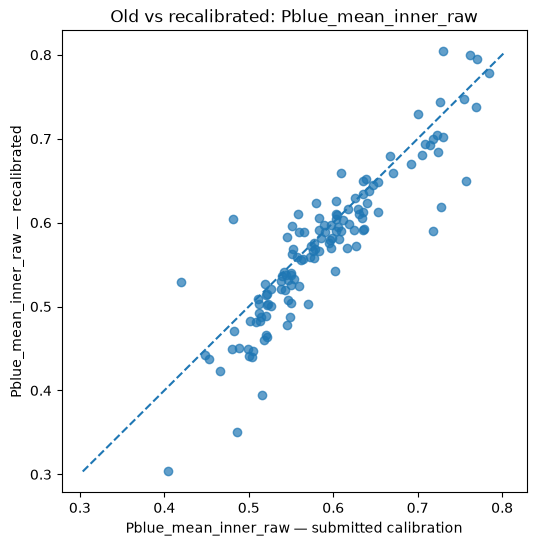

Pblue_mean_annulus
------------------
N                   = 139
Mean old            = 0.60292
Mean new            = 0.58789
Mean Δ(new-old)      = -0.01504
Median |Δ|           = 0.01621
Maximum |Δ|          = 0.18338
Spearman old vs new  = 0.9017  (p=9.89e-52)
Pearson old vs new   = 0.9013  (p=1.3e-51)


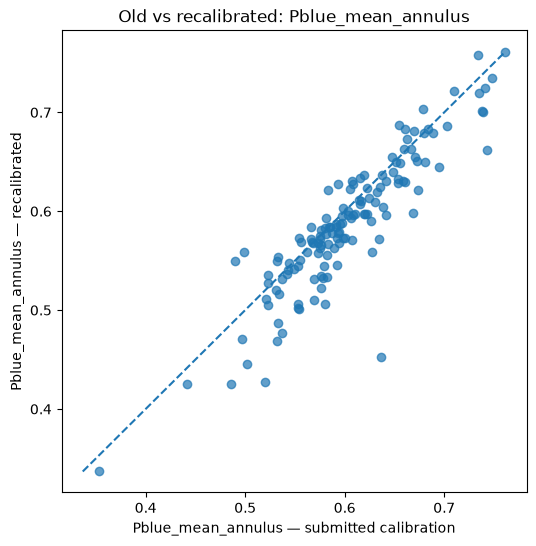

Pblue_mean_bgsub
----------------
N                   = 93
Mean old            = 0.12388
Mean new            = 0.12077
Mean Δ(new-old)      = -0.00311
Median |Δ|           = 0.01523
Maximum |Δ|          = 0.13845
Spearman old vs new  = 0.9879  (p=2.09e-75)
Pearson old vs new   = 0.9920  (p=1.69e-83)


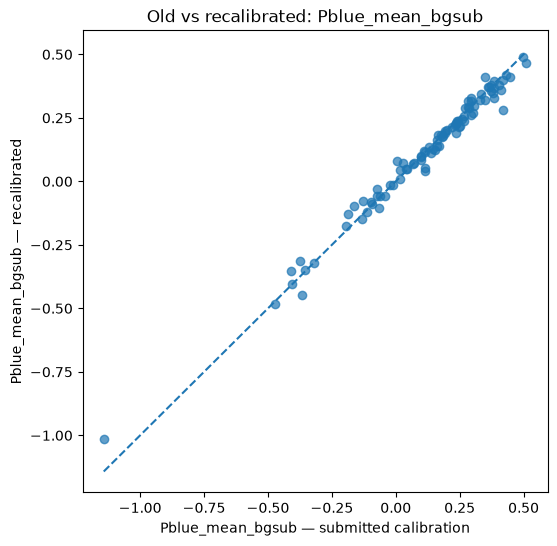

In [35]:
for metric in INTERMEDIATE:
    compare_metric(cmp, metric)


and finally compare the final $\Delta f_\mathrm{b}$ change against the original value.

/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_3803/1579238764.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cmp["recalibration_shift"] = (


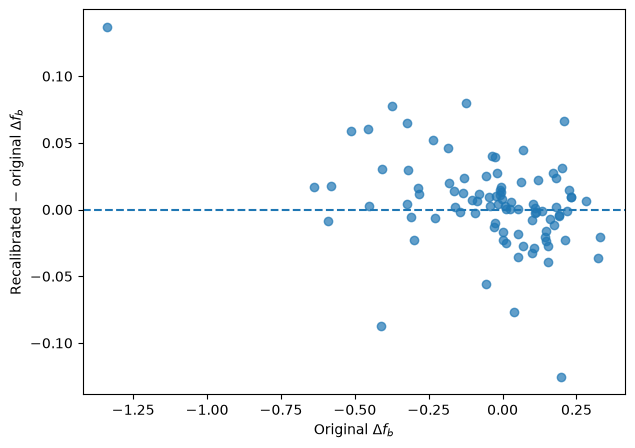

In [36]:
cmp["recalibration_shift"] = (
    cmp[f"{PRIMARY}_new"] -
    cmp[f"{PRIMARY}_old"]
)

fig, ax = plt.subplots(figsize=(7, 5))

valid = (
    np.isfinite(cmp[f"{PRIMARY}_old"]) &
    np.isfinite(cmp["recalibration_shift"])
)

ax.scatter(
    cmp.loc[valid, f"{PRIMARY}_old"],
    cmp.loc[valid, "recalibration_shift"],
    alpha=0.7
)

ax.axhline(0, linestyle="--")

ax.set_xlabel(r"Original $\Delta f_b$")
ax.set_ylabel(r"Recalibrated $-$ original $\Delta f_b$")

plt.show()

# Conclusion

Impact of corrected GMM calibration on the Paper 3 results. Recalibration of the GMM changes the absolute inner- and annular-region mean $P_\mathrm{blue}$ values at the $\sim 0.015$ level, but these shifts are largely common to both regions and substantially cancel after local-background subtraction. Consequently, the fiducial background-subtracted metric is highly stable $(\rho_\mathrm{old,new}=0.988)$, as is the final luminosity-residual diagnostic $\Delta f_\mathrm{b}(\rho_\mathrm{old,new}=0.984)$. The environmental correlations are effectively unchanged; in particular, the local GC-density relation remains $\rho\approx−0.442$. The high-density blue-deficit incidence decreases from $75\%$ to $66.7\%$, while the low-density incidence remains $20.8\%$, preserving the strong environmental contrast. Thus the corrected GMM calibration alters the absolute posterior scale but does not drive the principal environmental trends.